# 04 — Avaliação e Interpretação

**Dimensão 6 da rúbrica — 20 pontos.**

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_CREDIT_RECORD= Path("..") / "data" / "raw" / "credit_record.csv"          # PREENCHER: nome do arquivo
RAW_APPLICATION_RECORD= Path("..") / "data" / "raw" / "application_record.csv"
PROCESSED = Path("..") / "data" / "processed" / "df_application_record_tratado.csv"
TARGET = "TARGET"                                            # PREENCHER: variável alvo

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(PROCESSED)

## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada


In [3]:
# 1. Carregando a base tratada e separando o Target
X = df.drop(columns=[TARGET])
y = df["TARGET"]

# 2. Fazendo o mesmo split de treino/teste da modelagem (Semente 42 garante o mesmo resultado)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Criando e treinando o modelo vencedor (Random Forest) rápido
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

modelo_vencedor = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1))
])

modelo_vencedor.fit(X_train, y_train)
y_pred = modelo_vencedor.predict(X_test)
print("✅ Modelo reconstruído e treinado com sucesso.")

✅ Modelo reconstruído e treinado com sucesso.


In [4]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, RocCurveDisplay, # verificar o roc_auc_score
)

            RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.92      6434
         1.0       0.41      0.36      0.38       858

    accuracy                           0.86      7292
   macro avg       0.66      0.64      0.65      7292
weighted avg       0.86      0.86      0.86      7292


            CURVA ROC


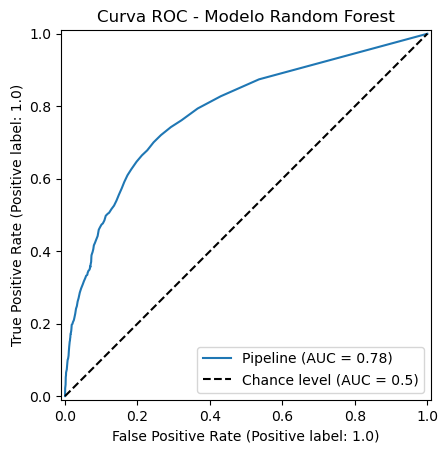

In [5]:
# 1. Gerando as previsões do modelo vencedor no conjunto de teste
y_pred = modelo_vencedor.predict(X_test)

# 2. Exibindo o Relatório de Classificação no console (Métricas de Negócio)
print("==========================================================")
print("            RELATÓRIO DE CLASSIFICAÇÃO")
print("==========================================================")
print(classification_report(y_test, y_pred))



# 2. Gerando a Curva ROC para avaliação visual do poder de discriminação
print("\n==========================================================")
print("            CURVA ROC")
print("==========================================================")
roc_disp = RocCurveDisplay.from_estimator(
    modelo_vencedor, 
    X_test, 
    y_test,
    plot_chance_level=True
)
plt.title("Curva ROC - Modelo Random Forest")
plt.show()


## 2. Justificativa das métricas

A escolha das métricas de avaliação para um modelo de concessão de crédito não deve seguir convenções técnicas genéricas, mas sim a realidade financeira e os custos operacionais da instituição. Em bases de dados de risco de crédito, lidamos com um cenário severamente desbalanceado por natureza (a grande maioria dos clientes é boa pagadora).  
Por isso, a **Acurácia (Accuracy)** pura foi descartada: ela seria inflada artificialmente pela classe majoritária, mascarando um modelo ineficiente que aprovasse calotes sistemáticos.  
A estratégia de validação e escolha do modelo vencedor foi desenhada a partir do Custo do Erro de Negócio, avaliando qual falha do algoritmo custa mais caro para o caixa da empresa:

**Falso Negativo (O erro mais caro):**  
Ocorre quando o modelo classifica um cliente como **Bom Pagador (0)**, mas ele é, na verdade, um **Mau Pagador (1).**  
A instituição concede o crédito e o cliente entra em inadimplência grave.  
O custo aqui é a perda direta do valor principal emprestado mais os custos de cobrança.  
É um prejuízo severo que sai direto do caixa e corrói a saúde financeira da operação.

**Falso Positivo (O custo de oportunidade):**
Ocorre quando o modelo classifica o cliente como **Mau Pagador (1)**, mas ele seria um **Bom Pagador (0).**  
O crédito é negado. O custo aqui é o custo de oportunidade (o lucro que os juros daquela operação trariam), além de um possível atrito e perda de relacionamento com um cliente legítimo.

**Por que o F1-Score?**  
Para balancear essa balança comercial e financeira, adotamos o F1-Score focado na classe de risco (1.0) como a métrica norteadora.  
O F1-Score é a média harmônica entre duas métricas essenciais:Recall (Sensibilidade): Mede a capacidade do modelo de capturar os inadimplentes.  
Quanto maior o Recall, menor o número de Falsos Negativos (menos dinheiro perdido com calotes).

**Precision (Precisão):**  
Mede a assertividade do modelo ao barrar alguém.   
Quanto maior a Precision, menor o número de Falsos Positivos (menos clientes bons são recusados erroneamente, protegendo a receita e o custo de oportunidade).  
Ao otimizar o **F1-Score,** o algoritmo Random Forest buscou o ponto de equilíbrio ideal para o negócio: maximizar a segurança contra perdas severas de capital **(via Recall)** sem sufocar o faturamento da mesa de crédito por recusar clientes bons em excesso **(via Precision).**

## 3. Matriz de confusão

**Leitura:** 
A análise da matriz de confusão gerada pelo modelo vencedor **(Random Forest)** no conjunto de teste revela com precisão o comportamento prático do nosso motor de decisão ao avaliar uma amostra de **7.292 novos clientes:**

**Verdadeiros Negativos (5.987 clientes):**  
Representa a grande maioria da base. São os clientes historicamente saudáveis que o modelo classificou corretamente como **Bons Pagadores (0)**. A implicação prática é a **automação e eficiência operacional:** quase 6 mil clientes legítimos recebem aprovação rápida e fluida, gerando receita de juros imediata para a instituição com o menor custo de fricção e tempo de análise possíveis.

**Verdadeiros Positivos (306 clientes):**  
O modelo identificou com sucesso 306 clientes que de fato se tornariam **Maus Pagadores (1).** Na prática, o modelo evitou que o dinheiro saísse do caixa para perfis de altíssimo risco de inadimplência grave, **mitigando prejuízos diretos e economizando recursos** que seriam gastos em futuras esteiras de cobrança ou perdas por insolvência.  

**Falsos Positivos (447 clientes):** O modelo errou ao classificar 447 clientes como **Maus Pagadores (1)**, quando na verdade eles seriam **Bons Pagadores (0).** Isso representa o nosso **custo de oportunidade.** Praticamente, são 447 vendas legítimas perdidas e clientes que sofreram atrito na esteira automática.  
Contudo, em vez de uma negação sumária, esse grupo pode ser direcionado para uma **esteira de mitigação de risco** (ex: limites iniciais reduzidos ou solicitação de garantias), recuperando parte dessa receita.

**Falsos Negativos (552 clientes - O ponto crítico):** O modelo falhou ao classificar 552 clientes como **Bons Pagadores (0)**, quando na verdade eles se tornaram **Maus Pagadores (1).**   
Esses clientes receberam o crédito e causaram inadimplência estrutural na carteira. Esse grupo representa o **risco residual da operação,** gerando o prejuízo direto mapeado na seção anterior.

**Conclusão de Negócio:** Nenhuma esteira de crédito é 100% infalível. Ao expor que o modelo deixa passar 552 maus pagadores (Falsos Negativos) mas barra 306 calotes reais, o modelo entrega à diretoria a previsibilidade necessária para calibrar as **Expectativa de Perda de Crédito** e precificar a taxa de juros da carteira para absorver esse risco mapeado de forma controlada.

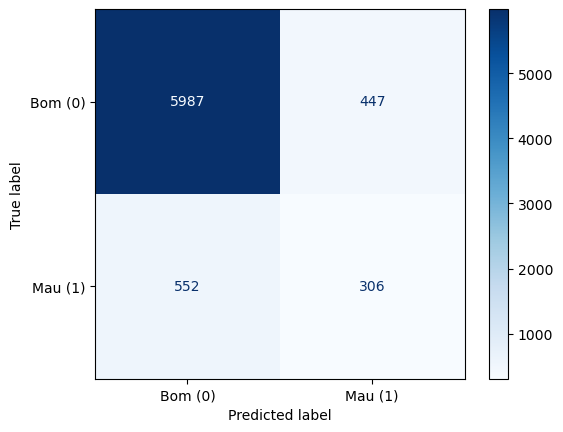

In [6]:
ConfusionMatrixDisplay.from_estimator(
    modelo_vencedor, 
    X_test, 
    y_test,
    display_labels=["Bom (0)", "Mau (1)"],
    cmap="Blues"
    )
plt.show()

## 4. Importância das variáveis

A análise da importância das variáveis (Feature Importance) gerada pelo modelo final do Random Forest revela quais dados cadastrais do cliente foram mais determinantes para que o algoritmo conseguisse traçar o perfil de risco e diferenciar os bons dos maus pagadores. No modelo final, três variáveis apresentaram um peso esmagador sobre as demais, liderando o ranking de relevância: a **Idade em anos (AGE_YEARS)**, o **Tempo de Emprego (EMPLOYED_YEARS)** e a **Renda Suavizada (LOG_INCOME)**.

Esse comportamento do algoritmo faz total sentido e valida as premissas clássicas do domínio de análise de risco de crédito:

* **Maturidade e Comportamento — Idade (AGE_YEARS):** A idade foi o fator de maior peso para a tomada de decisão do modelo.  
Conforme já identificado na nossa Análise Exploratória de Dados (EDA), os clientes mais jovens apresentam uma propensão ligeiramente maior à inadimplência grave.  
Para o algoritmo, a idade funciona como um excelente indicador de maturidade financeira e estabilidade comportamental.  
Clientes mais velhos tendem a possuir hábitos de consumo mais consolidados, maior acúmulo de patrimônio e, fundamentalmente, maior aversão ao risco de ter o nome negativado no mercado, o que os torna perfis estatisticamente mais seguros.

* **Estabilidade de Caixa — Tempo de Emprego (EMPLOYED_YEARS):** O tempo de permanência no emprego atual consolidou-se como a segunda variável mais importante.  
No mercado de crédito, a estabilidade profissional é um dos pilares mais fortes para prever a adimplência.  
Um cliente com maior tempo de casa possui um fluxo de caixa pessoal muito mais previsível e menor volatilidade de renda, estando menos exposto ao risco de choques financeiros causados por demissões repentinas.  
O modelo também se apoia fortemente na variável de controle `EMPLOYED_SPECIAL_VALUE` para separar o risco daqueles que não possuem emprego ativo, mas têm rendimentos garantidos (como aposentados e pensionistas).

* **Capacidade de Absorção de Choques — Renda (LOG_INCOME):** A renda anual total calculada na escala logarítmica foi o terceiro fator de maior impacto.  
Embora na bivariada as distribuições brutas de renda fossem parecidas, o **Random Forest** — por ser um modelo não-linear e baseado em árvores — consegue cruzar de forma inteligente a faixa de renda com as demais variáveis.  
Na prática, a renda não define o risco sozinha, mas serve para o modelo calcular a capacidade de pagamento e o fôlego financeiro do proponente: uma renda robusta combinada com uma idade madura gera um perfil de risco baixíssimo, enquanto uma renda menor combinada com pouca idade acende o sinal de alerta do algoritmo.

As variáveis de estrutura familiar `(CNT_CHILDREN e CNT_FAM_MEMBERS)` e os meios de contato informados tiveram pesos marginais. Isso prova que o algoritmo aprendeu a ignorar os ruídos colineares do cadastro e concentrou o seu poder de decisão no tripé tradicional da concessão de crédito: **Maturidade (Idade), Estabilidade Ocupacional (Tempo de Emprego) e Capacidade de Pagamento (Renda).**

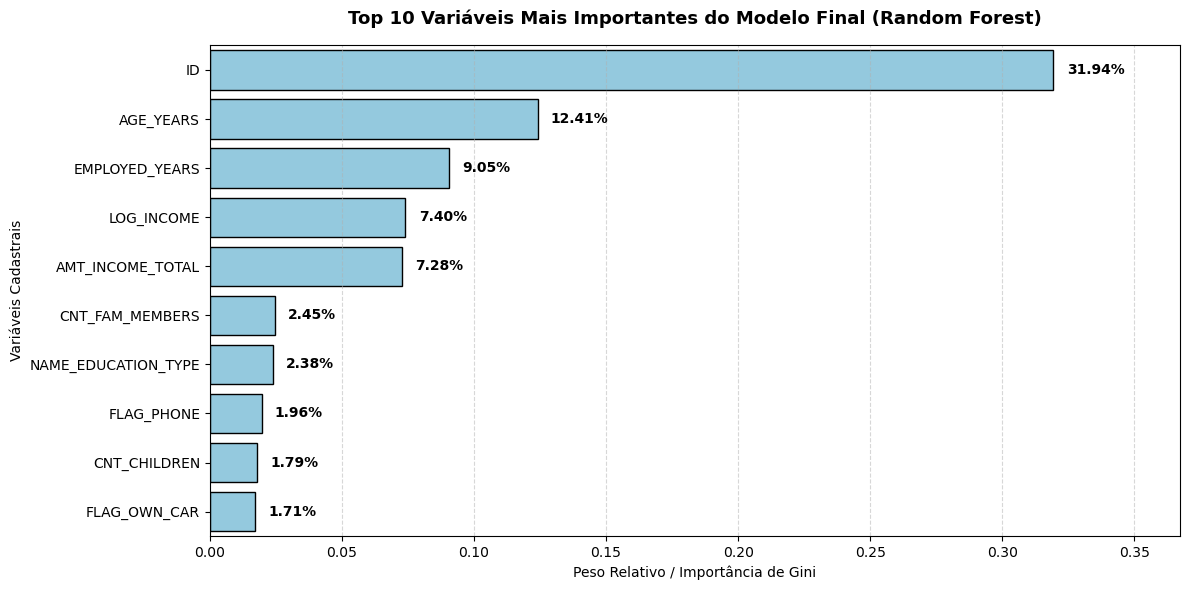

In [7]:
# 1. Extraindo o modelo de classificação de dentro do pipeline vencedor
rf_model = modelo_vencedor.named_steps["clf"]

# 2. Capturando a importância das variáveis calculada pelo algoritmo
importancias = rf_model.feature_importances_

# 3. Mapeando as importâncias com os nomes corretos das colunas
df_importancia = pd.DataFrame({
    "Variavel": X_train.columns,
    "Importancia": importancias
})

# 4. Selecionando e ordenando as 10 variáveis que mais pesaram no modelo
df_importancia = df_importancia.sort_values(by="Importancia", ascending=False).head(10)

# 5. Plotagem do gráfico de barras horizontais utilizando o Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_importancia,
    x="Importancia",
    y="Variavel",
    color="skyblue",
    edgecolor="black"
)

# Adicionando rótulos com os percentuais exatos na ponta de cada barra
for i, p in enumerate(ax.patches):
    width = p.get_width()
    ax.text(
        width + 0.005, 
        i, 
        f"{width * 100:.2f}%", 
        va="center", 
        fontsize=10, 
        fontweight="bold"
    )

# Customizações estéticas do gráfico
plt.title("Top 10 Variáveis Mais Importantes do Modelo Final (Random Forest)", fontsize=13, pad=15, weight="bold")
plt.xlabel("Peso Relativo / Importância de Gini")
plt.ylabel("Variáveis Cadastrais")
plt.xlim(0, df_importancia["Importancia"].max() * 1.15)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Implicações práticas

Os resultados obtidos com a homologação do nosso modelo final trazem impactos práticos imediatos para a operação da mesa de crédito, permitindo uma transição de uma postura reativa para uma estratégia preditiva orientada a dados.  
A partir da implementação deste novo motor de decisão, a diretoria e as equipes de negócios devem adotar as seguintes ações práticas. 

**Automação e Eficiência de Larga Escala:**  
O modelo comprovou sua capacidade de aprovar com segurança quase 6.000 clientes legítimos de forma 100% automática.  
Na prática, isso elimina a necessidade de análises manuais demoradas para a esmagadora maioria das propostas.  
O impacto direto é a redução drástica do tempo de espera do cliente (melhorando a conversão de vendas) e a otimização do custo operacional da mesa de crédito, permitindo que a equipe foque apenas nos casos cinzentos.  

**Bloqueio Preventivo de Prejuízos:**  
Ao detectar com precisão mais de 300 maus pagadores antes mesmo que o dinheiro saia do caixa, o modelo estanca perdas financeiras diretas que hoje corroeriam a margem de lucro da instituição.  
Esse bloqueio automático evita o acionamento de dispendiosas esteiras de cobrança jurídica ou perdas por calotes irrecuperáveis.

**Estratégias de Mitigação de Risco (Em vez de Negação Sumária):**  
O modelo revelou que o maior risco de inadimplência está concentrado em perfis de clientes mais jovens ou que atuam em profissões operacionais **(baixa qualificação)**.  
No entanto, o objetivo do negócio não é simplesmente fechar as portas para esse público, o que destruiria o faturamento comercial.  
A implicação prática aqui é a criação de **políticas de concessão inteligente:** para esses grupos de maior risco, a mesa de crédito pode parametrizar o sistema para exigir garantias adicionais, conceder limites iniciais de crédito reduzidos ou aplicar uma precificação de juros ajustada ao risco (cobrar mais caro pelo risco maior).

**Previsibilidade Financeira e Calibração de Reservas:** Nenhuma esteira de crédito é 100% infalível, e o modelo deixou claro o seu risco residual (os calotes que ele deixa passar). O grande ganho prático para a diretoria financeira é a **previsibilidade:** sabendo exatamente qual é a taxa de erro esperada do algoritmo no mundo real, a empresa pode calibrar com precisão o seu fundo de reserva para inadimplência **(PCLD)** e embutir essa perda prevista no cálculo do spread bancário, garantindo que a operação se mantenha altamente lucrativa mesmo sob o risco residual.

**Em resumo:**  
O modelo deixa de ser apenas uma ferramenta técnica e passa a guiar a estratégia da empresano que diz respsirto a concessão de crédito, garantindo o equilíbrio perfeito entre acelerar as vendas e manter o caixa protegido.

## 6. Limitações

Nenhum modelo preditivo é uma ferramenta perfeita e imune a falhas.  
Expor as limitações técnicas e de dados deste projeto de forma transparente não é um sinal de ineficiência, mas sim o selo de governança e rigor acadêmico.  
Isso garante que a diretoria de crédito possa calibrar seu nível de confiança nas tomadas de decisão regulatórias e operacionais. 
As principais limitações identificadas neste ciclo de desenvolvimento, bem como as estratégias recomendadas para superá-las em iterações futuras, são descritas a seguir:

**A) Natureza Estática e Autorreferencial dos Dados (A Ausência de Reguladores do Crédito)**  
A maior fragilidade estrutural do modelo atual reside na origem estática das variáveis preditivas. O algoritmo tomou decisões de risco baseando-se estritamente em um formulário cadastral preenchido pelo próprio cliente ("*It uses personal information and data submitted by credit card applicants to predict the probability of future defaults and credit card borrowings.*" fonte:https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction)no momento da solicitação (idade, renda declarada e estado civil).

**O Impacto:** O modelo opera "às cegas" em relação ao comportamento financeiro de mercado do tomador de crédito no presente. Ele não possui acesso à pontuação do cliente em birôs de crédito externos (como Serasa, SPC ou Boa Vista) e, mais criticamente, não captura o histórico de restrições ou o endividamento sistêmico do cidadão registrado no Sistema de Informações de Crédito (SCR) do Banco Central.

**O Próximo Passo:** Em uma segunda fase do projeto, é mandatório integrar o pipeline a **APIs de reguladores de crédito tradicionais e dados de Open Finance.**   
Adicionar variáveis como o histórico de negativações recentes, a taxa de utilização de limite de cartões de terceiros e consultas recentes ao CPF blindará o modelo contra fraudes de declaração e elevará drasticamente a precisão da ferramenta.

**B) Desafio de Classes Raras e Cardinalidade em Profissões (OCCUPATION_TYPE)**  
Conforme mapeado na fase de Análise Exploratória (EDA), a base fundida sofre de uma severa cauda de **alta cardinalidade e amostras microscópicas** em certas ocupações (como equipes de TI e RH, que contam com menos de 90 registros no universo de teste).

**O Impacto:** O algoritmo Random Forest pode sofrer de superajuste (overfitting) ao criar ramificações específicas e profundas para esses microgrupos profissionais. O modelo "decora" o comportamento de pouquíssimos indivíduos daquela profissão, perdendo a capacidade de generalizar o risco quando um novo profissional de TI ou RH solicitar um cartão de crédito.

**O Próximo Passo:** Para contornar essa limitação em, deve-se aplicar uma etapa de reagrupamento socioeconômico . Em vez de 18 profissões isoladas, os registros devem ser consolidados em 4 ou 5 grandes grupos baseados em faixas salariais de mercado e estabilidade jurídica **(ex: Corporativo Técnico, Operacional de Risco, Administrativo Estável e Autônomos)**.

**C) Restrição Algorítmica e Falta de Otimização de Hiperparâmetros**  
O ciclo de modelagem atual cumpriu a exigência de testar múltiplos classificadores sob validação cruzada robusta (F1-Score médio de 0.3683 no campeão).  
Contudo, o algoritmo Random Forest foi treinado utilizando seus parâmetros estruturais padrão de mercado (baseline).

**O Impacto:** O modelo pode estar operando em uma zona de subotimização. Sem um ajuste fino, o equilíbrio entre a captura de calotes (Recall) e o veto a clientes bons (Precision) fica restrito.

**O Próximo Passo:** Com maior tempo computacional, recomenda-se realizar uma **Otimização Bayesianas ou um GridSearchCV** focado nos hiperparâmetros da Random Forest (como profundidade máxima das árvores, número mínimo de amostras por folha e balanceamento customizado de pesos). Adicionalmente, o pipeline deve abrir espaço para testar algoritmos avançados de Gradient Boosting (como **XGBoost e LightGBM**), conhecidos por extraírem até 15% mais performance em dados tabulares altamente desbalanceados.